# Visualize JAX Function Samplers

This notebook demonstrates how to use and visualize the JAX-based function samplers defined in your project.

## 1. Setup and Imports

Import necessary libraries and configure the path to your project source code. We also enable `autoreload` so that changes made to your `.py` files are automatically picked up when you re-run cells.

In [1]:
%load_ext autoreload
%autoreload 2

import jax 
jax.config.update('jax_enable_checks', False)
import sys
import os
# import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple, Tuple, Dict, List
import jax.experimental.checkify as checkify # Import checkify
from hydra import initialize, compose
from omegaconf import DictConfig, OmegaConf


# IMPORTANT: Set this to the correct root directory of your project
# Use an absolute path for reliability
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Use the path you provided

if not os.path.isdir(root_dir):
    print(f"Error: Directory not found: {root_dir}")
    print("Please update the 'root_dir' variable to the correct path.")
else:
    if root_dir not in sys.path:
        sys.path.append(root_dir)
        print(f"Added {root_dir} to sys.path")

# Attempt to import your sampler functions
try:
    # Assuming your functions are in this specific module path
    from src.tasks.envs.jax_env_f.jax_function_samplers import (
        initialize_sampler,
        compute_y_sampler,
        create_env_params,
        FuncIndices,
        
        # Also import EnvParams if it's defined there, otherwise define it below
        EnvParams
    )
    
    print("Successfully imported sampler functions.")
except ImportError as e:
    print(f"Error importing sampler functions: {e}")
    print("Please ensure 'root_dir' is correct and the module path exists:")
    print("src.tasks.envs.function_envs.jax_samplers.jax_function_samplers")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

# --- Define EnvParams if not imported ---
# (Make sure this matches the definition expected by your functions)
# class EnvParams(NamedTuple):
#     action_dim: int
#     x_range: Tuple[float, float]
#     # Add other default parameters needed by your initializers
#     poly_degree: int = 2
#     poly_c_bounds: Tuple[float, float] = (5.0, 20.0)
#     poly_weight_bounds: Tuple[float, float] = (0.5, 2.0)
#     poly_optimum_range_factor: float = 0.9
#     ackley_a_bounds: Tuple[float, float] = (15.0, 20.0)
#     ackley_b_bounds: Tuple[float, float] = (0.1, 0.2)
#     ackley_c_bounds: Tuple[float, float] = (2 * jnp.pi, 2 * jnp.pi)
#     ackley_optimum_range_factor: float = 0.6

# Configure Matplotlib for inline plotting
# %matplotlib inline
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.style.use('seaborn-v0_8-darkgrid')

Added c:\Users\jimvo\Documents\Recurrent-PPO-Jax to sys.path


c:\Users\jimvo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully imported sampler functions.


## 2. Visualize a Single Sampled Function (1D)

Let's initialize one instance of a function (e.g., Polynomial, index 1) and plot it. We'll focus on 1D functions (`action_dim=1`) for easy visualization.

In [2]:


# Define your configuration path and name, similar to your @hydra.main decorator
config_path_relative = "../../../../config" # Adjusted path
config_name_value = "sweep_test" # Or whatever your main config file is named
version_base_value = None # Or your specific Hydra version base

# Initialize Hydra within a context manager.
# This is generally recommended for use in notebooks or scripts
# to avoid polluting the global Hydra state if you run multiple initializations.
with initialize(version_base=version_base_value, config_path=config_path_relative):
    # Compose your configuration
    # 'cfg' will be a DictConfig object, just like in your 'main' function
    cfg: DictConfig = compose(config_name=config_name_value)

    # Now you can convert it to a Python container (dict/list) with interpolations resolved
    # This is equivalent to: conf = OmegaConf.to_container(config, resolve=True)
    conf_dict = OmegaConf.to_container(cfg.task, resolve=True)
    conf_dict['function_types'] = ['poly', 'matern', 'ackley', 'neg_abs', 'gaussian']

    # 'conf_dict' now holds your configuration as a Python dictionary
    # You can use it for your testing purposes in the notebook
    print("Successfully loaded and resolved configuration:")





Successfully loaded and resolved configuration:


gaussian
--- Initialized Sampler Parameters ---


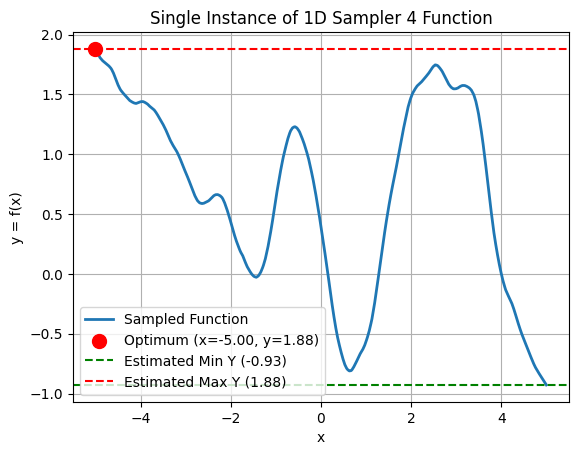

In [3]:
# --- Configuration ---
sampler_index_to_plot = 4  # 0 for Ackley, 1 for Polynomial
f_name =  FuncIndices._value2member_map_.get(sampler_index_to_plot).name

# Usage
print(f_name)  # Outputs: "poly"
# action_dimension = 1
x_min, x_max = -5.0, 5.0
num_points = 500 # Number of points for plotting the function shape





    
env_params = create_env_params(conf_dict)


# --- Initialize Sampler ---
key = jax.random.PRNGKey(0) # Use a fixed key for reproducibility

sampler_params = initialize_sampler(key, sampler_index_to_plot, env_params.action_dim, env_params) #this line still crashes

print("--- Initialized Sampler Parameters ---")

# --- Generate Data for Plotting ---
# Create a range of x values for plotting
bounds = conf_dict[f_name + '_env']['bounds']
x_plot = jnp.linspace(bounds[0], bounds[1], num_points).reshape(-1, env_params.action_dim)

# x_plot = jnp.expand_dims(x_plot, axis=0)  # Add a batch dimension


# # Compute y values using vmap for efficiency
# # Define a function that computes y for a single x using the initialized params
compute_single_y_jit = jax.jit(lambda x: compute_y_sampler(x, sampler_params, env_params))
# Map the JITted function over all x values
y_plot = jax.vmap(compute_single_y_jit, in_axes=0)(x_plot)

compute_batch_y = jax.vmap(lambda x: compute_y_sampler(x, sampler_params, env_params))

# JIT the whole vmapped operation
compute_batch_y_jit = jax.jit(compute_batch_y)

y_plot = compute_batch_y_jit(x_plot)

# --- Plotting ---
plt.figure()
plt.plot(x_plot.flatten(), y_plot.flatten(), label='Sampled Function', linewidth=2)

# Highlight Min/Max and Optimum
# for k in sampler_params.keys():
#     print(k["commmon"])

opt_x = sampler_params["common"]['optimum_point']
max_y = sampler_params["common"]['max_y']
min_y = sampler_params["common"]['min_y']

plt.scatter([opt_x], [max_y], color='red', s=100, zorder=5, label=f'Optimum (x={opt_x[0]:.2f}, y={max_y:.2f})')
plt.axhline(min_y, color='green', linestyle='--', label=f'Estimated Min Y ({min_y:.2f})')
plt.axhline(max_y, color='red', linestyle='--', label=f'Estimated Max Y ({max_y:.2f})')

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'Single Instance of 1D {func_name} Function')
plt.xlabel('x')
plt.ylabel('y = f(x)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Visualize Multiple Sampled Functions (1D)

Now, let's sample multiple functions (e.g., 5 Ackley functions, index 0) and plot them on the same graph to see the variety generated by the sampler.

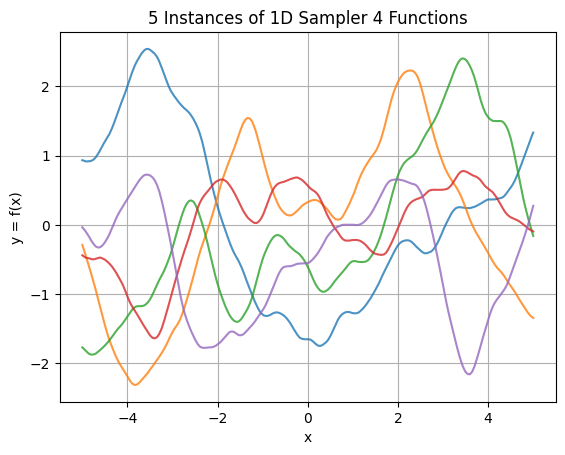

In [4]:
# --- Configuration ---
sampler_index_to_plot = 4  # 0 for Ackley, 1 for Polynomial
f_name =  FuncIndices._value2member_map_.get(sampler_index_to_plot).name
num_functions_to_plot = 5

num_points = 500 # Number of points for plotting the function shape

conf_dict = OmegaConf.to_container(cfg.task, resolve=True)
conf_dict['function_types'] = ['poly', 'matern', 'ackley', 'neg_abs', 'gaussian']
# conf_dict['action_dim'] = 2 
env_params = create_env_params(conf_dict)



key = jax.random.PRNGKey(99) # Starting key


bounds = conf_dict[f_name + '_env']['bounds']
x_plot = jnp.linspace(bounds[0], bounds[1], num_points).reshape(-1, env_params.action_dim)

plt.figure()

for i in range(num_functions_to_plot):
    # Get a new key for each function instance
    key, subkey = jax.random.split(key)

    # Initialize the sampler
    sampler_params = initialize_sampler(subkey, sampler_index_to_plot, env_params.action_dim, env_params)

    # Compute y values for this specific function instance
    compute_single_y = lambda x: compute_y_sampler(x, sampler_params, env_params)
    y_plot = jax.vmap(compute_single_y)(x_plot)

    # Plot this function instance
    
    # print("x", x_plot.flatten().shape, "y", y_plot.flatten().shape)
    plt.plot(x_plot.flatten(), y_plot.flatten(), label=f'Instance {i+1}', alpha=0.8)

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'{num_functions_to_plot} Instances of 1D {func_name} Functions')
plt.xlabel('x')
plt.ylabel('y = f(x)')
# plt.legend() # Legend might get crowded, optional
plt.grid(True)
plt.show()

## 4. Notes on 2D Visualization (Optional)

Visualizing 2D functions (`action_dim=2`) requires different plotting techniques:

1.  **Create a grid:** Use `jnp.meshgrid` to create X and Y coordinate matrices over the `x_range`.
2.  **Combine coordinates:** Stack the X and Y matrices to form input points `(x, y)` suitable for `compute_y_sampler` (shape `(num_points*num_points, 2)`).
3.  **Compute Z values:** Calculate the function output `Z` for all points on the grid.
4.  **Reshape Z:** Reshape the output `Z` back into a 2D grid matching the X and Y shapes.
5.  **Plot:** Use `plt.contourf` (filled contour) or `plt.imshow` (image plot) to visualize the 2D function landscape. You can also add the optimum point using `plt.scatter`.

Initializing sampler for action_dim=2...
Initialization complete.
--- Initialized Sampler Parameters (Common) ---
Shape of input points for vmap: (90000, 2)
Computing Y values using vmap...
Computation complete.
Shape of flat Y results: (90000,)
Shape of reshaped Y grid: (300, 300)
Generating 3D plot...


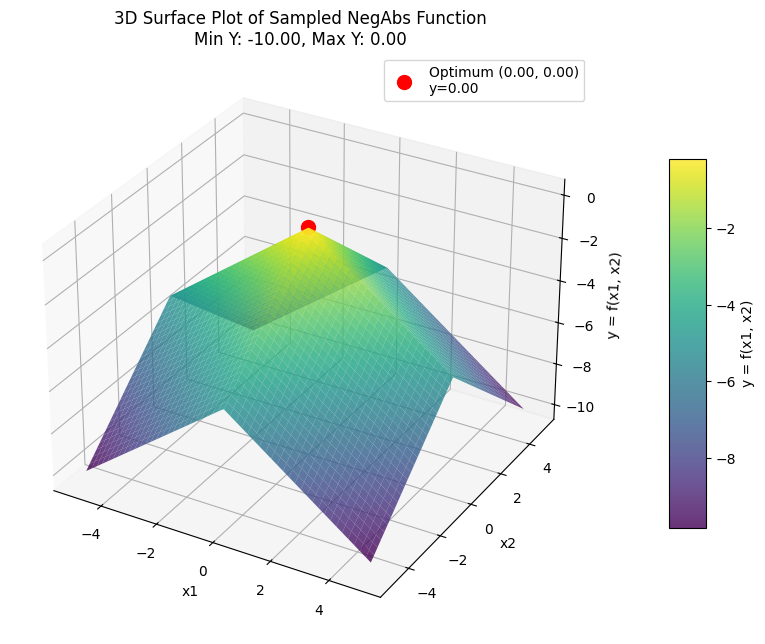

Plotting complete.


In [5]:
# === Imports ===

import matplotlib.cm as cm # For colormaps

# sampler_index_to_plot = 4  # 0 for Ackley, 1 for Polynomial
sampler_index_to_plot = 2  # 0 for Ackley, 1 for Polynomial
f_name =  FuncIndices._value2member_map_.get(sampler_index_to_plot).name

num_points_per_dim = 300 # Number of points for plotting the function shape

conf_dict = OmegaConf.to_container(cfg.task, resolve=True)
conf_dict['function_types'] = ['poly', 'matern', 'ackley', 'neg_abs', 'gaussian']
conf_dict['action_dim'] = 2 
env_params = create_env_params(conf_dict)






# === Initialize Sampler ===
key = jax.random.key(66)
print(f"Initializing sampler for action_dim={env_params.action_dim}...")
sampler_params = initialize_sampler(key, sampler_index_to_plot, env_params.action_dim, env_params)
print("Initialization complete.")
print("--- Initialized Sampler Parameters (Common) ---")

# === Generate Data for 3D Plotting ===
# (This part is identical to the 2D version)
bounds = conf_dict[f_name + '_env']['bounds']

x1_coords = jnp.linspace(bounds[0], bounds[1], num_points_per_dim)
x2_coords = jnp.linspace(bounds[0], bounds[1], num_points_per_dim)
X1, X2 = jnp.meshgrid(x1_coords, x2_coords)
x_plot_2d = jnp.stack([X1.ravel(), X2.ravel()], axis=-1)
print(f"Shape of input points for vmap: {x_plot_2d.shape}")

# === Compute Y Values ===
# (This part is identical to the 2D version)
compute_single_y = lambda x: compute_y_sampler(x, sampler_params, env_params)
compute_single_y_jit = jax.jit(compute_single_y)
print("Computing Y values using vmap...")
y_plot_flat = jax.vmap(compute_single_y_jit)(x_plot_2d)
print("Computation complete.")
print(f"Shape of flat Y results: {y_plot_flat.shape}")
Y = y_plot_flat.reshape(X1.shape) # Reshape Y to 2D grid
print(f"Shape of reshaped Y grid: {Y.shape}")

# === Plotting (3D Surface) ===
print("Generating 3D plot...")
fig = plt.figure(figsize=(10, 8)) # Adjust figure size for 3D
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
# cmap options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'jet', etc.
surf = ax.plot_surface(X1, X2, Y, cmap=cm.viridis, # Use a colormap
                       linewidth=0.2,              # Line width for the wireframe
                       antialiased=True,           # Make it smoother
                       alpha=0.8)                  # Slightly transparent

# Add a color bar which maps values to colors
fig.colorbar(surf, shrink=0.6, aspect=10, label='y = f(x1, x2)', pad=0.1)

# Highlight Optimum
opt_xy = sampler_params["common"]['optimum_point'] # Shape (2,)
max_y = sampler_params["common"]['max_y']          # Scalar Z value for optimum
min_y = sampler_params["common"]['min_y']          # Scalar min value

# Plot optimum point as a 3D scatter point
ax.scatter(opt_xy[0], opt_xy[1], max_y, color='red', s=100, depthshade=True,
           label=f'Optimum ({opt_xy[0]:.2f}, {opt_xy[1]:.2f})\ny={max_y:.2f}')

# Add labels and title
# Get function name
func_names = {0: 'Ackley', 1: 'Polynomial', 2: 'NegAbs', 3: 'Gaussian', 4: 'Matern52'}
func_name = func_names.get(sampler_index_to_plot, f'Sampler {sampler_index_to_plot}')

ax.set_title(f'3D Surface Plot of Sampled {func_name} Function\nMin Y: {min_y:.2f}, Max Y: {max_y:.2f}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y = f(x1, x2)')

# Adjust view angle if desired (optional)
# ax.view_init(elev=30, azim=-60) # Example: elevation 30, azimuth -60

ax.legend()
plt.show()
print("Plotting complete.")

In [6]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt


config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx


key = jr.key(123)



cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

In [7]:
import gpjax as gpx

n = 100
noise = 0.3

key, subkey = jax.random.split(key)
x = jax.random.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jax.random.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)


xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

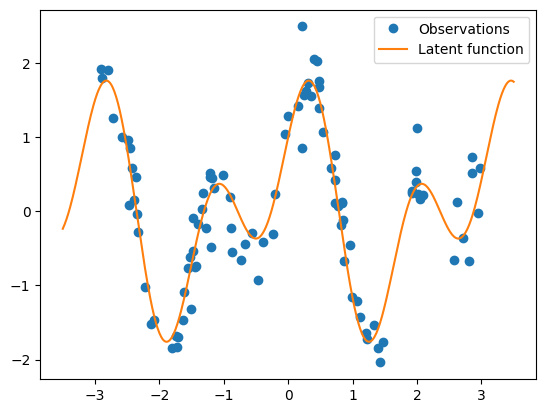

In [8]:
fig, ax = plt.subplots()
ax.plot(x, y, "o", label="Observations", color=cols[0])
ax.plot(xtest, ytest, label="Latent function", color=cols[1])
ax.legend(loc="best")

In [9]:
kernel = gpx.kernels.RBF()  # 1-dimensional input
print(type(kernel))
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

<class 'gpjax.kernels.stationary.rbf.RBF'>


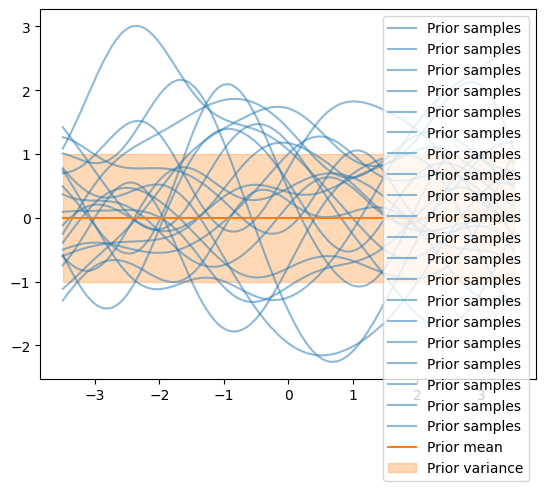

In [10]:
prior_dist = prior.predict(xtest)

prior_mean = prior_dist.mean
prior_std = prior_dist.variance
samples = prior_dist.sample(key=key, sample_shape=(20,))


fig, ax = plt.subplots()
ax.plot(xtest, samples.T, alpha=0.5, color=cols[0], label="Prior samples")
ax.plot(xtest, prior_mean, color=cols[1], label="Prior mean")
ax.fill_between(
    xtest.flatten(),
    prior_mean - prior_std,
    prior_mean + prior_std,
    alpha=0.3,
    color=cols[1],
    label="Prior variance",
)
ax.legend(loc="best")
# ax = clean_legend(ax)

In [11]:
likelihood = gpx.likelihoods.Gaussian(num_datapoints=D.n)
posterior = prior * likelihood

In [12]:
opt_posterior, history = gpx.fit_scipy(
    model=posterior,
    # we use the negative mll as we are minimising
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=D,
)
print(type(opt_posterior))

print(-gpx.objectives.conjugate_mll(opt_posterior, D))

Optimization terminated successfully.
         Current function value: 55.469226
         Iterations: 12
         Function evaluations: 19
         Gradient evaluations: 19
<class 'gpjax.gps.ConjugatePosterior'>
55.46922647118374


In [13]:
latent_dist = opt_posterior.predict(xtest, train_data=D)
predictive_dist = opt_posterior.likelihood(latent_dist)

predictive_mean = predictive_dist.mean
predictive_std = jnp.sqrt(predictive_dist.variance)

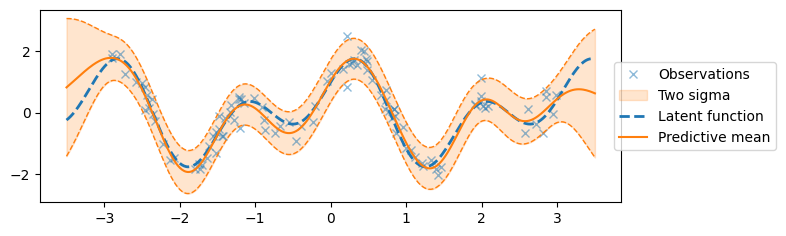

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 2.5))
ax.plot(x, y, "x", label="Observations", color=cols[0], alpha=0.5)
ax.fill_between(
    xtest.squeeze(),
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean - 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest,
    predictive_mean + 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    xtest, ytest, label="Latent function", color=cols[0], linestyle="--", linewidth=2
)
ax.plot(xtest, predictive_mean, label="Predictive mean", color=cols[1])
ax.legend(loc="center left", bbox_to_anchor=(0.975, 0.5))

init (1, 1) <class 'jaxlib.xla_extension.ArrayImpl'>

--- Starting Bayesian Optimization Loop ---

--- Iteration 1/10 ---
Sampled Batch:
  Point 1: X=[-1.36991064], Observed Y=-0.1490

--- Iteration 2/10 ---
Sampled Batch:
  Point 1: X=[-2.6546012], Observed Y=1.6627

--- Iteration 3/10 ---
Sampled Batch:
  Point 1: X=[-2.90234135], Observed Y=1.7177

--- Iteration 4/10 ---
Sampled Batch:
  Point 1: X=[-3.], Observed Y=1.4044

--- Iteration 5/10 ---
Sampled Batch:
  Point 1: X=[-3.], Observed Y=1.4044

--- Iteration 6/10 ---
Sampled Batch:
  Point 1: X=[-3.], Observed Y=1.4044

--- Iteration 7/10 ---
Sampled Batch:
  Point 1: X=[3.], Observed Y=0.4101

--- Iteration 8/10 ---
Sampled Batch:
  Point 1: X=[2.47224585], Observed Y=-0.2508

--- Iteration 9/10 ---
Sampled Batch:
  Point 1: X=[-2.77794156], Observed Y=1.6059

--- Iteration 10/10 ---
Sampled Batch:
  Point 1: X=[-2.80290875], Observed Y=1.6880

--- Optimization Finished ---
Total points sampled: 11
Best point observed: X = [-2

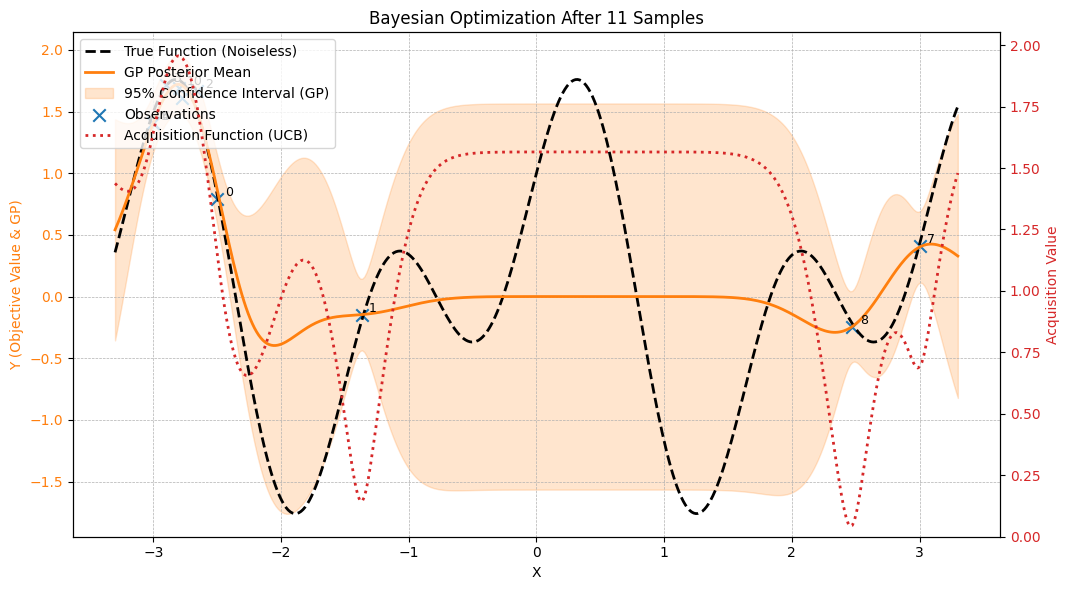

In [15]:
# Add matplotlib import at the top
import matplotlib.pyplot as plt
import matplotlib as mpl
from src.gp.gpjax import BayesianOptimizer, BOState, BOStaticParams, calculate_ucb
import jax.random as jr

# --- (Keep all the BO class/function definitions from the previous step) ---
# BOState, BOStaticParams, _build_likelihood, fit_gp_model, calculate_ucb,
# optimize_acquisition, update_step, suggest_batch_step, BayesianOptimizer

# --- Visualization Function (for 1D) ---

def plot_bo_1d(bo_optimizer: BayesianOptimizer,
               objective_function_true=None, # Optional true function
               acquisition_function=None,    # Optional acquisition function calculator
               title="Bayesian Optimization 1D"):
    """
    Generates plots to visualize the BO process for 1D input.

    Args:
        bo_optimizer: The trained BayesianOptimizer instance.
        objective_function_true: A callable that returns the true function value (noiseless).
        acquisition_function: A callable(x_eval, state, static_params) that returns acquisition values.
        title: The plot title.
    """
    if bo_optimizer.static_params.input_dim != 1:
        print("Visualization only implemented for 1D input.")
        return

    if bo_optimizer.posterior is None or bo_optimizer.state.dataset is None or bo_optimizer.state.dataset.n == 0:
        print("No data or posterior available to plot.")
        return
    


    X_observed = bo_optimizer.X
    Y_observed = bo_optimizer.Y
    final_state = bo_optimizer.state
    static_params = bo_optimizer.static_params
    posterior = final_state.posterior
    dataset = final_state.dataset

    min_b = static_params.min_bounds[0]
    max_b = static_params.max_bounds[0]
    plot_margin = (max_b - min_b) * 0.05
    xtest = jnp.linspace(min_b - plot_margin, max_b + plot_margin, 400).reshape(-1, 1)

   
    # Use the function that takes X, y arrays directly if that's needed by posterior.predict
    # Or use the dataset object if posterior.predict expects that.
    # Based on calculate_ucb needing to recreate Dataset, let's assume predict needs it too.
    latent_dist = posterior.predict(xtest, train_data=dataset)

   
    predictive_dist = posterior.likelihood(latent_dist)
    
    pred_mean = predictive_dist.mean
    pred_std = jnp.sqrt(predictive_dist.variance)
   

  

    # --- Plotting ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

    # Plot True Function (if provided)
    if objective_function_true:
        ytest_true = objective_function_true(xtest)
        ax1.plot(xtest, ytest_true, 'k--', linewidth=2, label="True Function (Noiseless)")

    # Plot GP Mean and Confidence Interval
    ax1.plot(xtest, pred_mean, color=cols[1], linewidth=2, label="GP Posterior Mean")
    ax1.fill_between(
        xtest.flatten(),
        pred_mean.flatten() - 1.96 * pred_std.flatten(),
        pred_mean.flatten() + 1.96 * pred_std.flatten(),
        alpha=0.2, color=cols[1], label="95% Confidence Interval (GP)"
    )

    # Plot Observed Points with Order Labels
    # Separate initial points from suggested points if desired, or just plot all
    num_observed = X_observed.shape[0]
    for i in range(num_observed):
        ax1.scatter(X_observed[i, 0], Y_observed[i, 0], color=cols[0], s=80, marker='x', label="Observations" if i == 0 else "")
        ax1.text(X_observed[i, 0] + (max_b - min_b)*0.01, # Offset text slightly
                 Y_observed[i, 0],
                 str(i), # Label with the sampling order index
                 fontsize=9, verticalalignment='bottom')

    ax1.set_xlabel("X")
    ax1.set_ylabel("Y (Objective Value & GP)", color=cols[1])
    ax1.tick_params(axis='y', labelcolor=cols[1])
    ax1.set_title(title)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)


    # --- Optional: Plot Acquisition Function ---
    if acquisition_function:
       
        if final_state.posterior is not None and final_state.dataset is not None:
                # Recreate acq_vals calculation logic similar to optimize_acquisition's obj_fn
                # This assumes acquisition_function has a compatible signature
                acq_vals = acquisition_function(xtest, final_state, static_params)

                ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
                color = cols[3]
                ax2.plot(xtest, acq_vals, color=color, linestyle=':', linewidth=2, label="Acquisition Function (UCB)")
                ax2.set_ylabel('Acquisition Value', color=color)
                ax2.tick_params(axis='y', labelcolor=color)
                # Optional: Fill under acquisition function
                # ax2.fill_between(xtest.flatten(), 0, acq_vals.flatten(), alpha=0.1, color=color)
                ax2.set_ylim(bottom=0) # Often makes sense for acquisition functions like UCB
                # Ask matplotlib to make room for the second ylabel
                fig.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent overlap

                # Combine legends
                lines, labels = ax1.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                # Remove duplicate 'Observations' label if present
                unique_labels = {}
                for line, label in zip(lines + lines2, labels + labels2):
                    if label not in unique_labels:
                        unique_labels[label] = line
                ax1.legend(unique_labels.values(), unique_labels.keys(), loc='upper left')


       
    else:
        ax1.legend(loc='upper left')


    plt.show()


# --- Example Usage (Modified for Visualization) ---
if __name__ == '__main__':

    # Define the 'environment' function (the function to optimize)
    def objective_function_batch(x_batch: jnp.ndarray) -> jnp.ndarray:
        results = []
        for i in range(x_batch.shape[0]):
            x = x_batch[i]; x_col = x.reshape(-1, 1)
            val = jnp.sin(4 * x_col) + jnp.cos(2 * x_col)
            key = jr.PRNGKey(int(jnp.sum(x)*1000 + jnp.prod(x)*500 + i*10))
            noise = 0.1
            noisy_val = val + jr.normal(key, shape=val.shape) * noise
            results.append(noisy_val.reshape(1, 1))
        return jnp.concatenate(results, axis=0)

    # Define the TRUE underlying function (for plotting comparison)
    def objective_function_true_1d(x: jnp.ndarray) -> jnp.ndarray:
         # Ensure input is column vector for the function if needed
         x_col = x.reshape(-1, 1)
         return jnp.sin(4 * x_col) + jnp.cos(2 * x_col)

    # --- BO Setup ---
    search_bounds = (jnp.array([-3.0]), jnp.array([3.0])) # 1D search space
    bo_optimizer = BayesianOptimizer(search_space_bounds=search_bounds, key=jr.PRNGKey(42))
    BATCH_SIZE = 1 # Use batch size 1 for clearer step-by-step visualization
    N_ITERATIONS = 10 # Number of points to sample after initial

    # --- Initial Data ---
    initial_X = jnp.array([[-2.5]]) # Start with one initial point
    initial_Y = objective_function_batch(initial_X)
    print("init", initial_Y.shape, type(initial_Y))
    bo_optimizer.update(initial_X, initial_Y)

    # --- The Optimization Loop ---
    print("\n--- Starting Bayesian Optimization Loop ---")
    for i in range(N_ITERATIONS):
        print(f"\n--- Iteration {i+1}/{N_ITERATIONS} ---")
        # 1. Get suggestion(s)
        suggested_x_batch = bo_optimizer.suggest(batch_size=BATCH_SIZE, n_restarts=10)

        # 2. Query the 'environment'
        observed_y_batch = objective_function_batch(suggested_x_batch)

        print(f"Sampled Batch:")
        for j in range(BATCH_SIZE):
             print(f"  Point {j+1}: X={suggested_x_batch[j]}, Observed Y={observed_y_batch[j].item():.4f}")

        # 3. Update the BO model
        bo_optimizer.update(suggested_x_batch, observed_y_batch)

    # --- Results ---
    print("\n--- Optimization Finished ---")
    print(f"Total points sampled: {bo_optimizer.X.shape[0]}")
    best_idx = jnp.argmax(bo_optimizer.Y)
    best_x_found = bo_optimizer.X[best_idx]
    best_y_found = bo_optimizer.Y[best_idx]
    print(f"Best point observed: X = {best_x_found}, Y = {best_y_found.item():.4f}")

    # --- Plotting ---
    if bo_optimizer.static_params.input_dim == 1:
         # Define a wrapper for the acquisition function calculation for plotting
         def plot_acquisition_ucb(x_eval, state, static_params):
              # Ensure x_eval is 2D for calculate_ucb
              x_eval = jnp.atleast_2d(x_eval)
              # Use vmap to efficiently calculate UCB over all x_eval points
              # Need to ensure calculate_ucb handles single points correctly if not using vmap
              # calculate_ucb expects a single point, optimize_acquisition calls it in a loop essentially
              # Let's calculate point-by-point for simplicity here, matching obj_fn logic
              ucb_values = []
              for k in range(x_eval.shape[0]):
                    ucb = calculate_ucb(x_eval[k],
                                        state.posterior,
                                        state.dataset.X, # Pass X directly
                                        state.dataset.y, # Pass y directly
                                        static_params.kappa)
                    ucb_values.append(ucb)
              return jnp.array(ucb_values)


         plot_bo_1d(bo_optimizer,
                    objective_function_true=objective_function_true_1d,
                    acquisition_function=plot_acquisition_ucb, # Pass the UCB calculator
                    title=f"Bayesian Optimization After {bo_optimizer.X.shape[0]} Samples")

--- Initialized Sampler Parameters ---
x_batch (1, 1)
noiseless_y_batch [-218.130419] [[-1.48333655]]
<class 'jaxlib.xla_extension.ArrayImpl'> (1, 1)
Initial point: X=[[-1.48333655]], Y=[[-218.18019508]]

--- Starting Bayesian Optimization Loop ---

--- Iteration 1/5 ---
x_batch (2, 1)
noiseless_y_batch [-333.39860741  -72.38579997] [[-2.75886367]
 [ 0.75089384]]
Sampled Batch:
  Point 1: X=[-2.75886367], Observed Y=-333.3467
  Point 2: X=[0.75089384], Observed Y=-72.3513

--- Iteration 2/5 ---


c:\Users\jimvo\Documents\Recurrent-PPO-Jax\src\gp\gpjax.py:300: UserWarning: Acquisition optimization failed. Returning random point.
  x_next, _, updated_key = optimize_acquisition(temp_state_for_opt, static_params, n_restarts)


x_batch (2, 1)
noiseless_y_batch [  11.99065653 -304.62387841] [[ 4.00937111]
 [-2.46339932]]
Sampled Batch:
  Point 1: X=[4.00937111], Observed Y=11.9688
  Point 2: X=[-2.46339932], Observed Y=-304.6000

--- Iteration 3/5 ---
x_batch (2, 1)
noiseless_y_batch [-235.18974965  -50.96739625] [[-1.68958872]
 [ 1.21764288]]
Sampled Batch:
  Point 1: X=[-1.68958872], Observed Y=-235.1525
  Point 2: X=[1.21764288], Observed Y=-50.8823

--- Iteration 4/5 ---
x_batch (2, 1)
noiseless_y_batch [-3.24810147 -3.20943862] [[2.71835627]
 [2.72019415]]
Sampled Batch:
  Point 1: X=[2.71835627], Observed Y=-3.2955
  Point 2: X=[2.72019415], Observed Y=-3.1668

--- Iteration 5/5 ---
x_batch (2, 1)
noiseless_y_batch [-387.53709395  -61.79648242] [[-3.28316068]
 [ 0.97317483]]
Sampled Batch:
  Point 1: X=[-3.28316068], Observed Y=-387.5228
  Point 2: X=[0.97317483], Observed Y=-61.6948

--- Optimization Finished ---
Total points sampled: 11
Best observed point: X = [4.00937111], Y = 11.9688
True optimum po

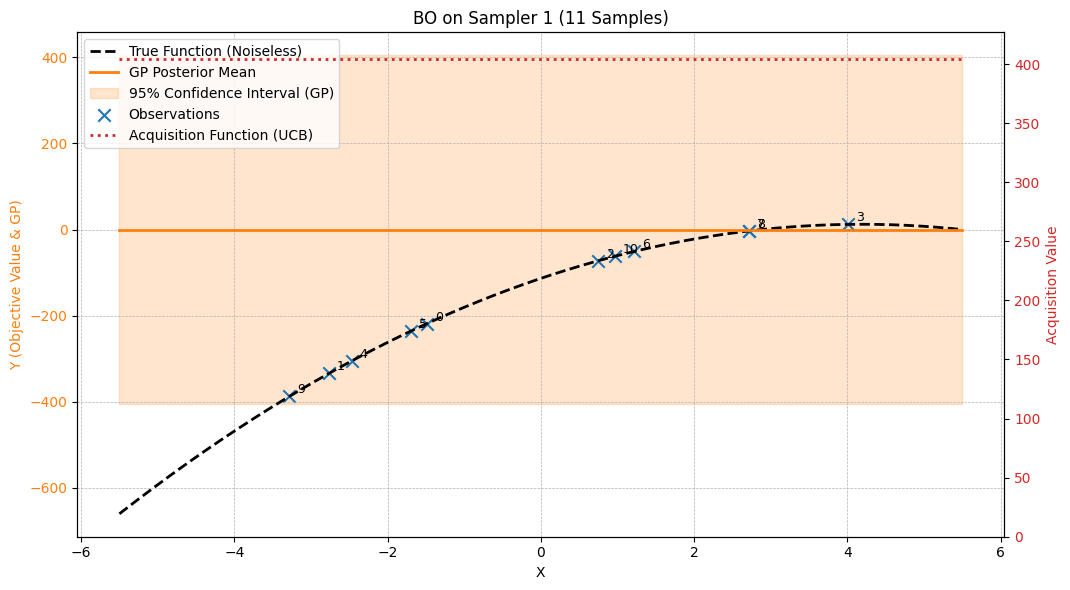

In [ ]:
import jax.random as jr


sampler_index_to_run = 1# Choose the sampler index you want BO to optimize
num_points_plot = 400 # Plotting resolution
key = jr.PRNGKey(0) # Main random key

conf_dict = OmegaConf.to_container(cfg.task, resolve=True)
conf_dict['function_types'] = ['poly', 'matern', 'ackley', 'neg_abs', 'gaussian']
# conf_dict['action_dim'] = 2 

env_params = create_env_params(conf_dict) # Create environment parameters


bounds = conf_dict[f_name + '_env']['bounds']
x_min = bounds[0]
x_max = bounds[1]



# Initialize the specific sampler instance for this run
key, subkey = jr.split(key)
try:
    sampler_params = initialize_sampler(subkey, sampler_index_to_run, env_params.action_dim, env_params)
    print("--- Initialized Sampler Parameters ---")
    # print(sampler_params) # Optional: print to verify
except Exception as e:
    print(f"ERROR initializing sampler: {e}")
    # Handle error appropriately, maybe exit
    exit()

# --- Define Objective Functions for BO and Plotting ---

# 1. Objective function for the BO loop (takes batch, returns NOISY observations)
#    We will add noise here, assuming compute_y_sampler is noiseless.
#    If compute_y_sampler IS noisy, just use it directly (after vmapping).

compute_batch_y_sampler_jit = jax.jit(jax.vmap(
    lambda x: compute_y_sampler(x, sampler_params, env_params), # Close over initialized params
    in_axes=0
))

def objective_for_bo(x_batch: jnp.ndarray, key: jr.PRNGKey) -> jnp.ndarray:
    """Wrapper for BO: calls user's function and adds noise."""
    # Get noiseless values
    
    print("x_batch", x_batch.shape)
    noiseless_y_batch = compute_batch_y_sampler_jit(x_batch)
    
    print("noiseless_y_batch", noiseless_y_batch, x_batch)

    # Add observation noise (adjust noise level as needed)
    noise_level = 0.00 # Example noise std dev
    noise = jr.normal(key, shape=noiseless_y_batch.shape) * noise_level

    # Reshape to (batch_size, 1) expected by BO update
    return (noiseless_y_batch + noise).reshape(-1, 1)

# 2. True (noiseless) objective function for plotting
#    Needs to accept the plot's xtest input shape (num_points_plot, action_dim)
def true_objective_for_plot(xtest: jnp.ndarray) -> jnp.ndarray:
    """Wrapper for plotting: calls user's noiseless function."""
    # Use the same JITted batch computation
    y_true = compute_batch_y_sampler_jit(xtest)
    # Reshape for plotting if necessary (plot_bo_1d expects (N,1))
    return y_true.reshape(-1, 1)

# --- BO Setup ---
search_bounds = (jnp.array([x_min]), jnp.array([x_max])) # Use bounds from env
key, bo_key = jr.split(key)
bo_optimizer = BayesianOptimizer(search_space_bounds=search_bounds, key=bo_key)
BATCH_SIZE = 1    # Set BO batch size (e.g., 1 for sequential)
N_ITERATIONS = 5   # Number of BO steps (samples) after initial

# --- Initial Data ---
# Sample initial point(s) within bounds
key, init_key = jr.split(key)
initial_X = jr.uniform(init_key, (1, env_params.action_dim), minval=x_min, maxval=x_max)
# Evaluate initial point(s) - needs a key for potential noise
key, obj_key = jr.split(key)
initial_Y = objective_for_bo(initial_X, obj_key)
print(type(initial_Y), initial_Y.shape) # Check shape
bo_optimizer.update(initial_X, initial_Y)
print(f"Initial point: X={initial_X}, Y={initial_Y}")

# --- The Optimization Loop ---
print("\n--- Starting Bayesian Optimization Loop ---")
for i in range(N_ITERATIONS):
    print(f"\n--- Iteration {i+1}/{N_ITERATIONS} ---")
    # 1. Get suggestion(s) from BO
    # The suggest method updates the optimizer's internal key state
    suggested_x_batch = bo_optimizer.suggest(batch_size=BATCH_SIZE, n_restarts=10)

    # 2. Query the objective function (needs a key for noise)
    key, obj_key = jr.split(bo_optimizer.state.key) # Use key from BO state for consistency
    observed_y_batch = objective_for_bo(suggested_x_batch, obj_key)

    print(f"Sampled Batch:")
    for j in range(suggested_x_batch.shape[0]): # Use actual batch size suggested
            print(f"  Point {j+1}: X={suggested_x_batch[j]}, Observed Y={observed_y_batch[j].item():.4f}")

    # 3. Update the BO model
    # Note: update internally gets a new state but doesn't consume the key passed in
    bo_optimizer.update(suggested_x_batch, observed_y_batch)
    # We manually update the key in the class after suggest, so no need to pass obj_key back


# --- Results ---
print("\n--- Optimization Finished ---")
print(f"Total points sampled: {bo_optimizer.X.shape[0]}")
best_idx = jnp.argmax(bo_optimizer.Y) # Best OBSERVED point
best_x_found = bo_optimizer.X[best_idx]
best_y_found = bo_optimizer.Y[best_idx]
print(f"Best observed point: X = {best_x_found}, Y = {best_y_found.item():.4f}")
# Compare to known optimum if available in sampler_params
if "common" in sampler_params and "optimum_point" in sampler_params["common"]:
    true_opt_x = sampler_params["common"]["optimum_point"]
    true_opt_y = sampler_params["common"]["max_y"] # Assuming maximization
    print(f"True optimum point:  X = {true_opt_x}, Y = {true_opt_y.item():.4f}")


# --- Plotting ---
if bo_optimizer.static_params.input_dim == 1:
    # Define the acquisition function calculator for plotting
    def plot_acquisition_ucb(x_eval, state, static_params):
            x_eval = jnp.atleast_2d(x_eval)
            ucb_values = []
            # Ensure dataset exists before accessing X, y
            if state.dataset is None or state.dataset.n == 0: return jnp.zeros(x_eval.shape[0]) # Or handle error

            X_train_plot = state.dataset.X
            y_train_plot = state.dataset.y
            for k in range(x_eval.shape[0]):
                # Check posterior exists
                if state.posterior is None: ucb = jnp.nan; continue
                ucb = calculate_ucb(x_eval[k],
                                    state.posterior,
                                    X_train_plot,
                                    y_train_plot,
                                    static_params.kappa)
                ucb_values.append(ucb)
            return jnp.array(ucb_values)

    plot_title = f'BO on Sampler {sampler_index_to_run} ({bo_optimizer.X.shape[0]} Samples)'
    plot_bo_1d(bo_optimizer,
                objective_function_true=true_objective_for_plot, # Pass the wrapper
                acquisition_function=plot_acquisition_ucb,
                title=plot_title)
else:
    print("Plotting only implemented for 1D environments.")